In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/titanic.csv")

In [3]:
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Filas: 891
Columnas: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
import os

os.listdir("./data")

['titanic.csv',
 'titanic_clean.csv',
 'titanic_feature.csv',
 'titanic_repositorio.csv']

In [5]:
df = pd.read_csv("./data/titanic.csv")

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

Filas: 891
Columnas: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
395,396,0,3,"Johansson, Mr. Erik",male,22.0,0,0,350052,7.7958,NaN,S
748,749,0,1,"Marvin, Mr. Daniel Warner",male,19.0,1,0,113773,53.1000,D30,S
695,696,0,2,"Chapman, Mr. Charles Henry",male,52.0,0,0,248731,13.5000,NaN,S


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [8]:
porcentaje_nulos = (
    df.isnull()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(porcentaje_nulos)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


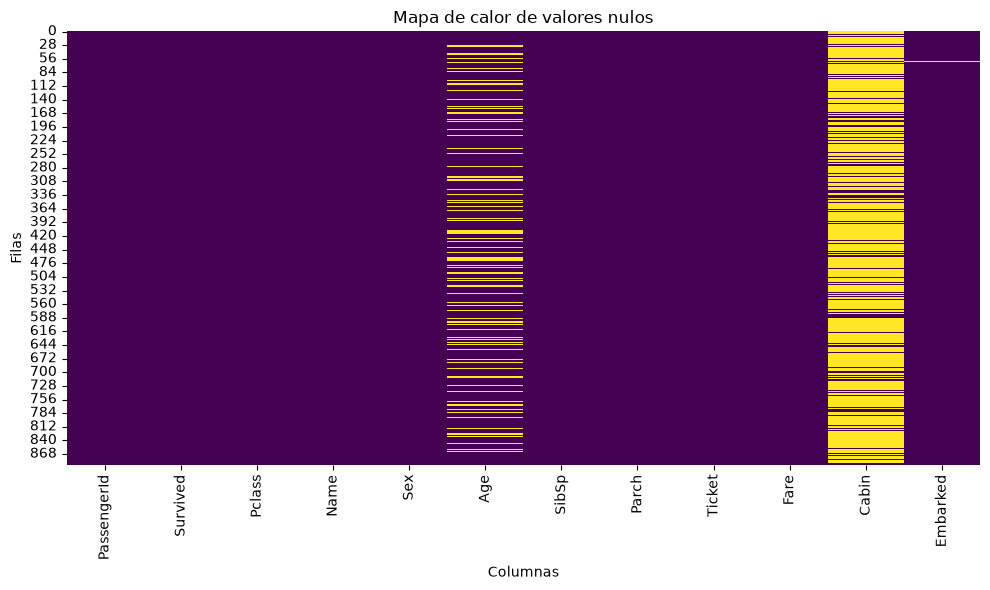

In [9]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Mapa de calor de valores nulos")
plt.xlabel("Columnas")
plt.ylabel("Filas")
plt.tight_layout()
plt.show()

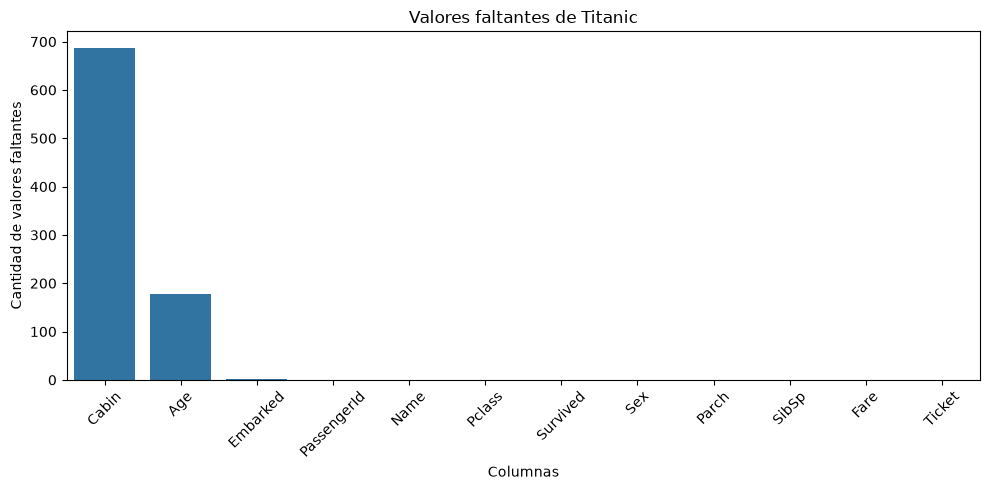

In [10]:
total_nulos = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=total_nulos.index,
    y=total_nulos.values
)

plt.title("Valores faltantes de Titanic")
plt.xlabel("Columnas")
plt.ylabel("Cantidad de valores faltantes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
df.drop(columns=["Cabin"], inplace=True)

In [12]:
media_edad = df["Age"].mean()

df["Age"] = df["Age"].fillna(media_edad)

print(f"Media de edad utilizada: {media_edad:.2f}")

Media de edad utilizada: 29.70


In [13]:
moda_embarked = df["Embarked"].mode()[0]

df["Embarked"] = df["Embarked"].fillna(moda_embarked)

print(f"Moda utilizada en Embarked: {moda_embarked}")

Moda utilizada en Embarked: S


In [14]:
duplicados = df.duplicated().sum()

print(f"Filas duplicadas: {duplicados}")

Filas duplicadas: 0


In [15]:
df.drop(
    columns=["Name", "Ticket", "PassengerId"],
    inplace=True
)

In [16]:
print(
    f"Después de limpiar df: "
    f"{df.shape[0]} filas y {df.shape[1]} columnas."
)

df.head()

Después de limpiar df: 891 filas y 8 columnas.


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [17]:
df.to_csv("./data/titanic_clean.csv", index=False)

print("Archivo data/titanic_clean.csv guardado correctamente.")

Archivo data/titanic_clean.csv guardado correctamente.
